In [1]:
# Importing relevant packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Seaborn settings
sns.set_theme()
sns.set_palette("pastel")

In [3]:
# Importing superstore csv
store = pd.read_csv('data/superstore.csv', encoding='latin1')

## Data Cleaning

In [4]:
# Finding potential null values, data types
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
# Fidning potential duplicated values
store.duplicated().sum()

np.int64(0)

In [6]:
# Formatting column headings
store.columns = store.columns.str.lower().str.replace(' ', '_')

In [7]:
# Dropping Row ID
store = store.drop('row_id', axis=1)

In [8]:
# Assigning datetime format to relevant columns
store['order_date'] = pd.to_datetime(store['order_date'])
store['ship_date'] = pd.to_datetime(store['ship_date'])

In [9]:
# Calculating time for order to be delivered, assigning to new variable 'shipping_time'
store['shipping_time'] = store['ship_date'] - store['order_date']

In [10]:
store.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,...,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_time
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3 days
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3 days
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4 days
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7 days
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7 days


In [11]:
# Overview of dataframe
store.describe()

,order_date,ship_date,postal_code,sales,quantity,discount,profit,shipping_time
count,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994
mean,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,3 days 22:59:46.311787072
min,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0 days 00:00:00
25%,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,3 days 00:00:00
50%,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,4 days 00:00:00
75%,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,5 days 00:00:00
max,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7 days 00:00:00
std,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1 days 17:56:29.766161104


In [12]:
# Calculating Average Order Value
sum(store['sales']) / len(store)

229.85800083049827

In [13]:
# Calculating Units per Transaction
sum(store['quantity']) / len(store)

3.789573744246548

## Graphs

In [14]:
top_sales_states = (
    store.groupby('state', as_index=False)['sales']
    .sum()
    .nlargest(5, 'sales')
)

bottom_sales_states = (
    store.groupby('state', as_index=False)['sales']
    .sum()
    .nsmallest(5, 'sales')
)

Text(0.5, 1.0, 'Bottom 5 States by Revenue')

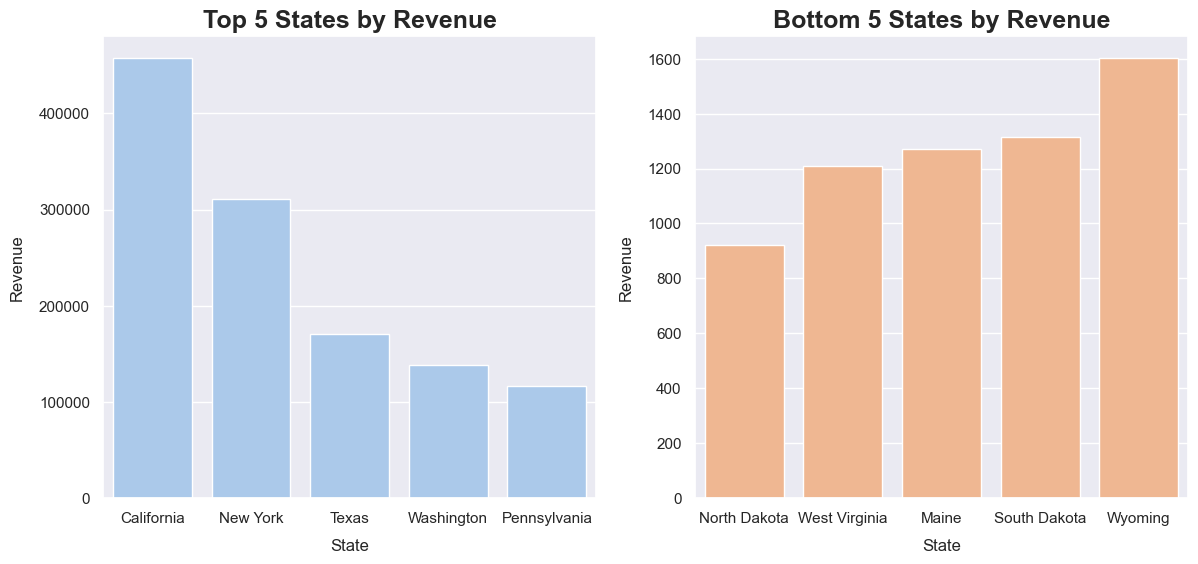

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=top_sales_states, x='state', y='sales', ax=ax[0])
ax[0].set_xlabel('State', labelpad=10)
ax[0].set_ylabel('Revenue', labelpad=10)
ax[0].set_title('Top 5 States by Revenue', fontsize=18, fontweight='bold')

sns.barplot(data=bottom_sales_states, x='state', y='sales', ax=ax[1], color='#ffb482')
ax[1].set_xlabel('State', labelpad=10)
ax[1].set_ylabel('Revenue', labelpad=10)
ax[1].set_title('Bottom 5 States by Revenue', fontsize=18, fontweight='bold')

In [16]:
top_profit_states = (
    store.groupby('state', as_index=False)['profit']
    .sum()
    .nlargest(5, 'profit')
)

bottom_profit_states = (
    store.groupby('state', as_index=False)['profit']
    .sum()
    .nsmallest(5, 'profit')
)

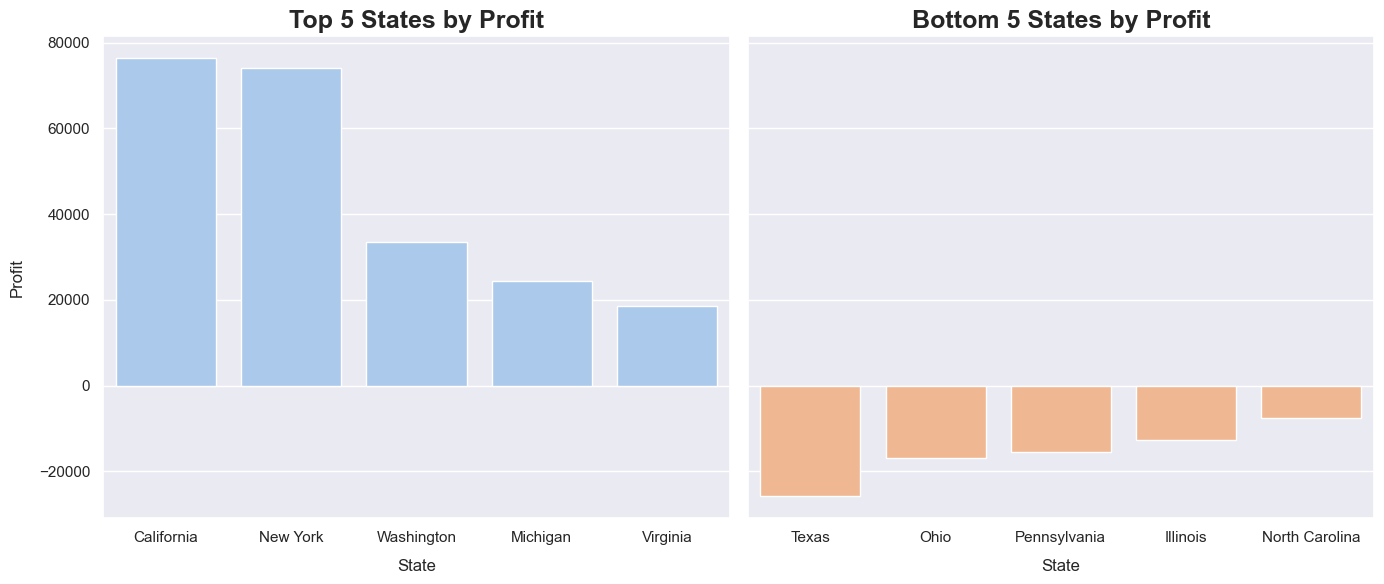

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Left plot: Profit
sns.barplot(data=top_profit_states, x='state', y='profit', ax=ax[0])
ax[0].set_xlabel('State', labelpad=10)
ax[0].set_ylabel('Profit', labelpad=10)
ax[0].set_title('Top 5 States by Profit', fontsize=18, fontweight='bold')

# Right plot: Sales
sns.barplot(data=bottom_profit_states, x='state', y='profit', ax=ax[1], color='#ffb482')
ax[1].set_xlabel('State', labelpad=10)
ax[1].set_ylabel('Revenue', labelpad=10)
ax[1].set_title('Bottom 5 States by Profit', fontsize=18, fontweight='bold')

plt.tight_layout()

In [18]:
store['category']

0             Furniture
1             Furniture
2       Office Supplies
3             Furniture
4       Office Supplies
             ...       
9989          Furniture
9990          Furniture
9991         Technology
9992    Office Supplies
9993    Office Supplies
Name: category, Length: 9994, dtype: object

Text(0.5, 1.0, 'Quantity of products sold per category')

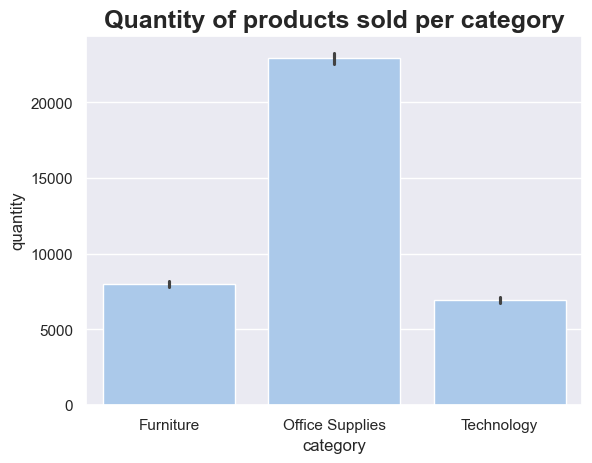

In [19]:
sns.barplot(data=store, x='category', y='quantity', estimator=sum)

plt.title('Quantity of products sold per category', fontsize=18, fontweight='bold')

In [20]:
# Average sales price (per item sold)

store['sales'].sum() / store['quantity'].sum()

np.float64(60.65537085258627)

Text(0.5, 1.0, 'Total average sales price (per order)')

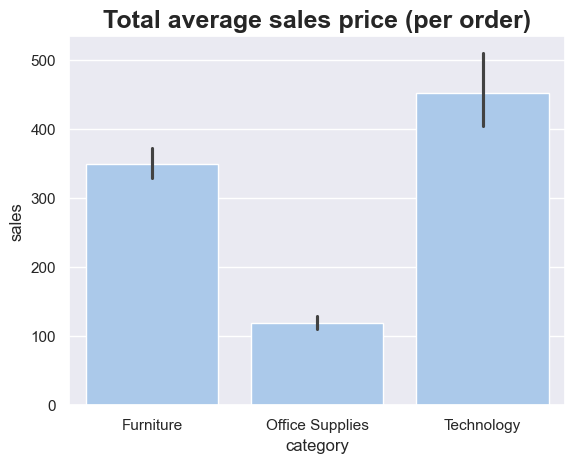

In [21]:
# Average sales price (per transaction)
sns.barplot(data=store, x='category', y='sales')
plt.title('Total average sales price (per order)', fontsize=18, fontweight='bold')

<Axes: xlabel='category', ylabel='quantity'>

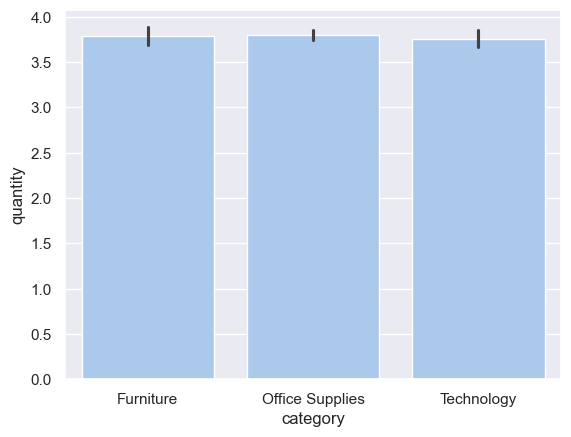

In [22]:
# UPT (units per transaction)
sns.barplot(data=store, x='category', y='quantity')

In [23]:
store['shipping_time'].value_counts()

shipping_time
4 days    2774
5 days    2169
2 days    1334
6 days    1203
3 days    1005
7 days     621
0 days     519
1 days     369
Name: count, dtype: int64

In [24]:
store['shipping_days'] = (
    store['ship_date'] - store['order_date']
).dt.days

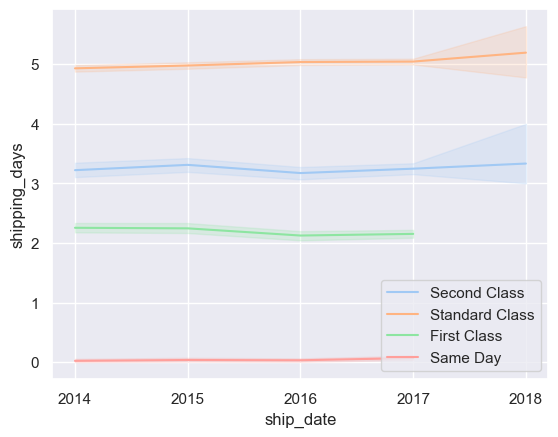

In [25]:
sns.lineplot(data=store, x= store['ship_date'].dt.year, y='shipping_days', hue='ship_mode') 
plt.xticks([2014, 2015, 2016, 2017, 2018])
plt.legend(loc='lower right')
plt.show()

([<matplotlib.axis.XTick at 0x145ac6b5a90>,
 [Text(2014, 0, '2014'),
  Text(2015, 0, '2015'),
  Text(2016, 0, '2016'),
  Text(2017, 0, '2017')])

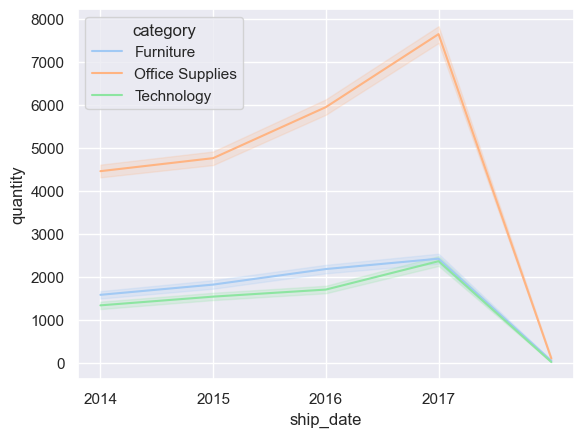

In [26]:
sns.lineplot(data=store, x= store['ship_date'].dt.year, y='quantity', hue='category', estimator=sum)
plt.xticks([2014, 2015, 2016, 2017])

In [27]:
def profit_by_state_category(df, n=5, highest=True):

    state_profits = (
        df.groupby('state')['profit']
        .sum()
    )

    if highest:
        states = state_profits.nlargest(n).index
    else:
        states = state_profits.nsmallest(n).index

    result = (
        df.groupby(['state', 'category'], as_index=False)['profit']
        .sum()
    )

    result = result[result['state'].isin(states)]

    return result

In [28]:
state_profits = (
    store.groupby('state')['profit']
    .sum()
)

In [29]:
top_profit_states = profit_by_state_category(store)

In [30]:
bottom_profit_states = profit_by_state_category(
    store,
    highest=False
)

<Axes: xlabel='state', ylabel='profit'>

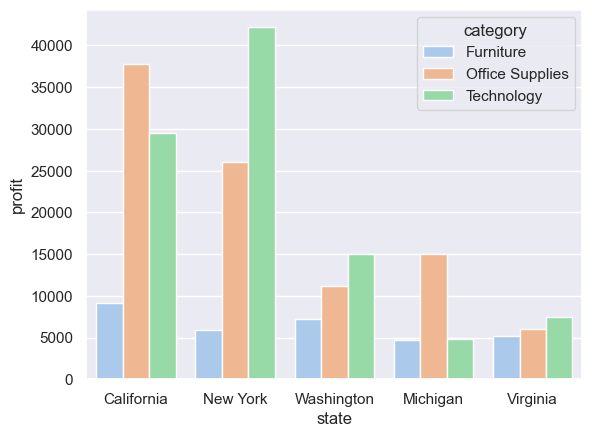

In [31]:
sns.barplot(
    data=top_profit_states,
    x='state',
    y='profit',
    hue='category',
    estimator=sum,
    order=state_profits.nlargest(5).index
)

<Axes: xlabel='state', ylabel='profit'>

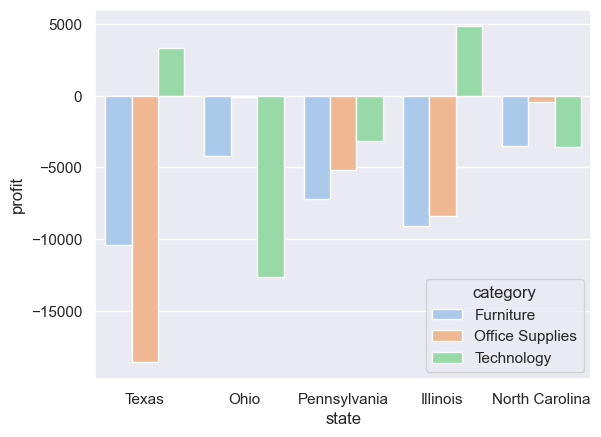

In [32]:
sns.barplot(data=bottom_profit_states, x='state', y='profit', hue='category', estimator=sum, order=state_profits.nsmallest(5).index)

<Axes: ylabel='sub-category'>

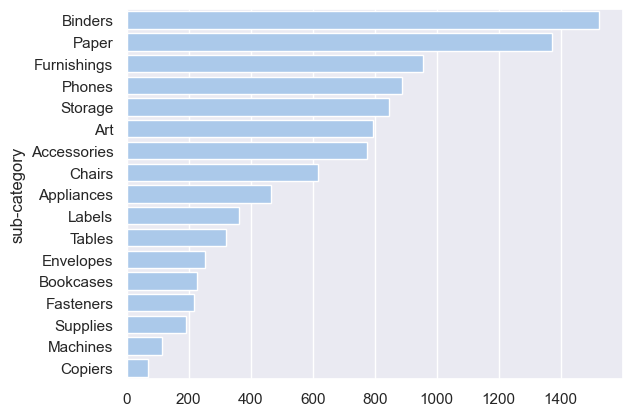

In [33]:
subcat_counts = store['sub-category'].value_counts()

sns.barplot(
    x=subcat_counts.values,
    y=subcat_counts.index
)

Text(0.5, 0, 'Year')

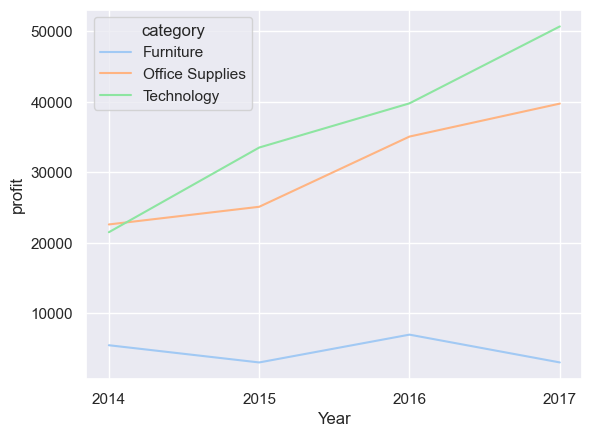

In [34]:
sns.lineplot(data=store, x= store['order_date'].dt.year, y='profit', hue='category', estimator=sum, errorbar=None)
plt.xticks([2014, 2015, 2016, 2017])
plt.xlabel('Year')

In [35]:
store

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_time,shipping_days
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3 days,3
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3 days,3
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4 days,4
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7 days,7
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7 days,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,...,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2 days,2
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,5 days,5
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,5 days,5
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,5 days,5


## Export CSV

In [36]:
# store.to_csv('store_clean.csv', index=False)